In [ ]:
import h5py
import numpy as np

model_path = r"D:\EO-Methane\scripts\dl-water-bodies-01\Mullen2023-UNET-models\single_class_slope_best_model.h5"

with h5py.File(model_path, "r") as f:
    
    # Print top-level keys
    print("Top-level keys:", list(f.keys()))
    
    # Print full layer structure with weight shapes
    def print_weights(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"  {name:80s} {obj.shape}")
    
    if "model_weights" in f:
        print("\n── Model weights ────────────────────────────────")
        f["model_weights"].visititems(print_weights)
    
    # Also extract and print the model config JSON if present
    if "model_config" in f.attrs:
        import json
        config = json.loads(f.attrs["model_config"])
        print("\n── Model config (first 3000 chars) ──────────────")
        print(json.dumps(config, indent=2)[:3000])

Top-level keys: ['model_weights', 'optimizer_weights']

── Model weights ────────────────────────────────
  block1a_bn/block1a_bn/beta:0                                                     (64,)
  block1a_bn/block1a_bn/gamma:0                                                    (64,)
  block1a_bn/block1a_bn/moving_mean:0                                              (64,)
  block1a_bn/block1a_bn/moving_variance:0                                          (64,)
  block1a_dwconv/block1a_dwconv/depthwise_kernel:0                                 (3, 3, 64, 1)
  block1a_project_bn/block1a_project_bn/beta:0                                     (32,)
  block1a_project_bn/block1a_project_bn/gamma:0                                    (32,)
  block1a_project_bn/block1a_project_bn/moving_mean:0                              (32,)
  block1a_project_bn/block1a_project_bn/moving_variance:0                          (32,)
  block1a_project_conv/block1a_project_conv/kernel:0                               (1

: 

## Darcy Training Data

### 1. Split Classified rasters into 1024x1024 tiles

In [2]:
import os
import rasterio
from rasterio.windows import Window, bounds as window_bounds
import geopandas as gpd
from shapely.geometry import box

def split_raster(input_raster, output_dir, tile_width=1024, tile_height=1024,
                  tile_shapefile="tile_grid.shp"):
    os.makedirs(output_dir, exist_ok=True)
    
    tile_records = []  # collect tile footprints + metadata

    with rasterio.open(input_raster) as src:
        meta = src.meta.copy()
        width = src.width
        height = src.height
        crs = src.crs
        
        for j in range(0, height, tile_height):
            for i in range(0, width, tile_width):
                
                w = min(tile_width, width - i)
                h = min(tile_height, height - j)
                
                window = Window(i, j, w, h)
                transform = rasterio.windows.transform(window, src.transform)
                
                meta.update({
                    'height': h,
                    'width': w,
                    'transform': transform
                })
                
                tile_filename = f"tile_{i}_{j}.tif"
                output_path = os.path.join(output_dir, tile_filename)

                if not os.path.exists(output_path):
                    with rasterio.open(output_path, 'w', **meta) as dst:
                        dst.write(src.read(window=window))
                
                # Compute tile footprint in world coordinates
                minx, miny, maxx, maxy = window_bounds(window, src.transform)
                geom = box(minx, miny, maxx, maxy)
                
                tile_records.append({
                    "filename": tile_filename,
                    "col_off": i,
                    "row_off": j,
                    "width": w,
                    "height": h,
                    "geometry": geom
                })
    
    # Build and save the tile grid shapefile
    tile_gdf = gpd.GeoDataFrame(tile_records, crs=crs)
    tile_shp_path = os.path.join(output_dir, tile_shapefile)
    tile_gdf.to_file(tile_shp_path)
    
    print(f"Saved {len(tile_gdf)} tile footprints to {tile_shp_path}")
    return tile_gdf


split_raster(r"M:\data\PlanetScope\2024-07-15\1b865f4e-ce2f-4bc4-8a21-60fd9c1d1076\PSScene\20240716_151643_20_24c8_3B_AnalyticMS_SR_8b_reproject_bandmath.tif", 
             "M:/data/PlanetScope/training/20240716_151643_20_24c8", tile_shapefile='20240716_151643_20_24c8.shp')


Saved 168 tile footprints to M:/data/PlanetScope/training/20240716_151643_20_24c8\20240716_151643_20_24c8.shp


,filename,col_off,row_off,width,height,geometry
0,tile_0_0.tif,0,0,1024,1024,"POLYGON ((1656106.597 1570051.47, 1656106.597 ..."
1,tile_1024_0.tif,1024,0,1024,1024,"POLYGON ((1659169.049 1570051.47, 1659169.049 ..."
2,tile_2048_0.tif,2048,0,1024,1024,"POLYGON ((1662231.502 1570051.47, 1662231.502 ..."
3,tile_3072_0.tif,3072,0,1024,1024,"POLYGON ((1665293.955 1570051.47, 1665293.955 ..."
4,tile_4096_0.tif,4096,0,1024,1024,"POLYGON ((1668356.408 1570051.47, 1668356.408 ..."
...,...,...,...,...,...,...
163,tile_9216_11264.tif,9216,11264,1024,92,"POLYGON ((1683668.672 1539151.799, 1683668.672..."
164,tile_10240_11264.tif,10240,11264,1024,92,"POLYGON ((1686731.125 1539151.799, 1686731.125..."
165,tile_11264_11264.tif,11264,11264,1024,92,"POLYGON ((1689793.577 1539151.799, 1689793.577..."
166,tile_12288_11264.tif,12288,11264,1024,92,"POLYGON ((1692856.03 1539151.799, 1692856.03 1..."


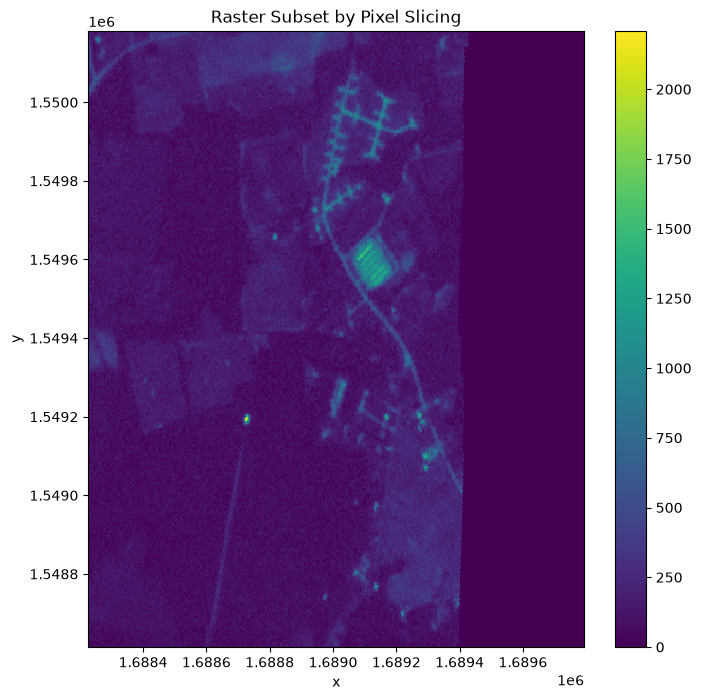

In [28]:
# from rasterio.plot import show

# with rasterio.open(r"M:\data\PlanetScope\training\20240716_151643_20_24c8\PS\tile_11264_7168.tif") as src:
#     data_mask = src.read_masks(1)
#     show(src)
#     print(src.profile)
# # data_mask.plot()

import rioxarray as rxr
import matplotlib.pyplot as plt

# 1. Open the raster file
raster = rxr.open_rasterio(r"M:\data\PlanetScope\training\20240716_151643_20_24c8\PS\tile_11264_7168.tif")#, masked=True)

# 2. Slice using pixel indices (e.g., first band, rows 100-500, columns 200-600)
# Structure: [band_index, row_slice, column_slice]
raster_subset = raster[0, 500:1024, 500:1024]

# 3. Plot the pixel-sliced subset
fig, ax = plt.subplots(figsize=(8, 8))
raster_subset.plot(ax=ax, cmap="viridis")
ax.set_title("Raster Subset by Pixel Slicing")
plt.show()


In [27]:
raster

<xarray.DataArray (band: 10, y: 1024, x: 1024)> Size: 42MB
[10485760 values with dtype=float32]
Coordinates:
  * band         (band) int64 80B 1 2 3 4 5 6 7 8 9 10
  * y            (y) float64 8kB 1.552e+06 1.552e+06 ... 1.549e+06 1.549e+06
  * x            (x) float64 8kB 1.687e+06 1.687e+06 ... 1.69e+06 1.69e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [22]:
nodata_mask = (data_mask == 0) | (data_mask == 255) | (data_mask == None)

In [23]:
nodata_mask[-1:-5][-1:-5]

array([], shape=(0, 1024), dtype=bool)

### 2. Rasterize polygons

In [30]:
import glob
import numpy as np
from rasterio.features import rasterize

def rasterize_tiles(tile_dir, shapefile_path, output_dir, 
                     burn_value=1, nodata_value=255, 
                     all_touched=False, skip_empty_tiles=True,
                     tile_list=None,
                     image_nodata_value=0):
    """
    For each tile raster in tile_dir, rasterize the water-body shapefile
    onto that tile's exact grid, then mask out no-data areas.
    
    - burn_value: pixel value for water
    - nodata_value: value to assign where the source tile has no-data
    - skip_empty_tiles: if True, don't write a label file for tiles that are 100% no-data
    - tile_list: optional list restricting which tiles to process. Accepts either:
        - filenames only, e.g. ["tile_0_0.tif", "tile_1000_0.tif"]
        - full paths, e.g. ["./output_tiles/tile_0_0.tif"]
        - a glob pattern string, e.g. "tile_0_*.tif"
      If None, all tiles matching tile_dir/tile_*.tif are processed.
        - image_nodata_value: the pixel value in the SOURCE tiles that represents no-data
      (used as a fallback/primary check when the raster's nodata metadata isn't set)
   """
    os.makedirs(output_dir, exist_ok=True)
    
    gdf = gpd.read_file(shapefile_path)
    
    # Resolve which tiles to process
    if tile_list is None:
        tile_paths = sorted(glob.glob(os.path.join(tile_dir, "tile_*.tif")))
    elif isinstance(tile_list, str):
        # treat as a glob pattern relative to tile_dir
        tile_paths = sorted(glob.glob(os.path.join(tile_dir, tile_list)))
    else:
        # treat as an explicit list of filenames or paths
        tile_paths = []
        for t in tile_list:
            if os.path.isabs(t) or os.path.dirname(t):
                tile_paths.append(t)
            else:
                tile_paths.append(os.path.join(tile_dir, t))
        tile_paths = sorted(tile_paths)
    
    # Warn about any requested tiles that don't actually exist
    missing = [t for t in tile_paths if not os.path.exists(t)]
    if missing:
        print(f"Warning: {len(missing)} requested tile(s) not found, skipping:")
        for m in missing:
            print(f"  {m}")
    tile_paths = [t for t in tile_paths if os.path.exists(t)]
    
    if not tile_paths:
        print("No valid tiles to process.")
        return
    
    written, skipped = 0, 0
    
    for tile_path in tile_paths:
        with rasterio.open(tile_path) as src:
            transform = src.transform
            out_shape = (src.height, src.width)
            crs = src.crs
            
            band = src.read(10)  # read actual pixel values
            
            # Combine metadata mask AND explicit pixel-value check
            meta_mask = src.read_masks(10) == 0          # True where metadata says nodata
            value_mask = band == image_nodata_value       # True where pixel value == nodata sentinel
            nodata_mask = meta_mask | value_mask
            
            if skip_empty_tiles and nodata_mask.all():
                skipped += 1
                continue
        
        if gdf.crs != crs:
            gdf_tile = gdf.to_crs(crs)
        else:
            gdf_tile = gdf
        
        shapes = [(geom, burn_value) for geom in gdf_tile.geometry if geom is not None]
        
        if shapes:
            label = rasterize(
                shapes,
                out_shape=out_shape,
                transform=transform,
                fill=0,
                dtype="uint8",
                all_touched=all_touched
            )
        else:
            label = np.zeros(out_shape, dtype="uint8")
        
        # Apply combined no-data mask AFTER rasterizing, so it always wins
        label[nodata_mask] = nodata_value
        
        out_meta = {
            "driver": "GTiff",
            "height": out_shape[0],
            "width": out_shape[1],
            "count": 1,
            "dtype": "uint8",
            "crs": crs,
            "transform": transform,
            "nodata": nodata_value,
            "compress": "LZW"
        }
        
        tile_name = os.path.basename(tile_path)
        label_name = tile_name.replace("tile_", "label_")
        out_path = os.path.join(output_dir, label_name)
        
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(label, 1)
        
        written += 1
    
    print(f"Wrote {written} label tiles, skipped {skipped} all-nodata tiles.")


# Example usage — process only specific tiles by filename
rasterize_tiles(
    tile_dir="M:/data/PlanetScope/training/20240716_151643_20_24c8/PS",
    shapefile_path=r"M:\data\Shapefiles\handdrawn_polygons\20240716_151643_20_24c8\20240716_151643_20_24c8.shp",
    output_dir="M:/data/PlanetScope/training/20240716_151643_20_24c8/labels",
    tile_list=["tile_8192_6144.tif", "tile_9216_6144.tif", "tile_10240_6144.tif", "tile_11264_6144.tif",
               "tile_8192_7168.tif", "tile_9216_7168.tif", "tile_10240_7168.tif", "tile_11264_7168.tif",
               "tile_11264_8192.tif"]
)


Wrote 9 label tiles, skipped 0 all-nodata tiles.
